### 24RB1075 小嶋将太郎

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.neighbors import NearestNeighbors

In [3]:
# スイスロール型のデータ準備
m = 1000
k = 10
noise = 0.05

X, t = make_swiss_roll(n_samples=m, noise=noise, random_state=123)

In [4]:
# k近傍の特定
nn = NearestNeighbors(n_neighbors = k+1)
nn.fit(X)

distances, indices = nn.kneighbors(X)

neighbors_idx = indices[:, 1:]

In [5]:
# 局所重みの導出
W = np.zeros((m, m))

for i in range(m):
    idx = neighbors_idx[i]
    X_neighbors = X[idx]

    Z = X_neighbors - X[i]
    C = Z @ Z.T

    C += 1e-3 * np.trace(C) * np.eye(k)

    ones = np.ones(k)
    w_tmp = np.linalg.solve(C, ones)
    w = w_tmp / np.sum(w_tmp)

    W[i, idx] = w

In [6]:
# 固有値分解
I = np.eye(m)
M = (I - W).T @ (I - W)

# 固有値・固有ベクトル
eigenvalues, eigenvectors = np.linalg.eigh(M)

X_scratch = eigenvectors[:, 1:3]

In [7]:
# sklearnのLLE
lle = LocallyLinearEmbedding(n_neighbors=k, n_components=2, method='standard', random_state=123)
X_sklearn = lle.fit_transform(X)

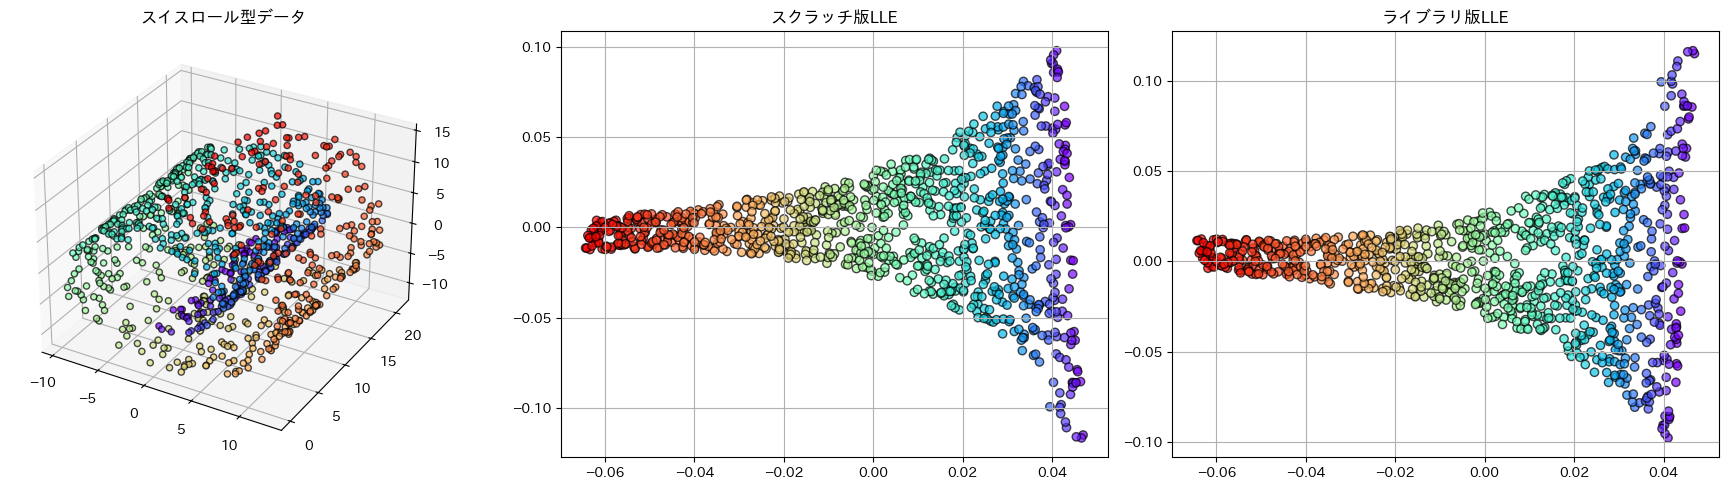

In [8]:
# 結果の比較
fig = plt.figure(figsize=(18,5))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.rainbow, edgecolor='k', alpha=0.7)
ax1.set_title("スイスロール型データ")

ax2 = fig.add_subplot(1, 3, 2)
sc2 = ax2.scatter(X_scratch[:, 0], X_scratch[:, 1], c=t, cmap=plt.cm.rainbow, edgecolor='k', alpha=0.7)
ax2.set_title("スクラッチ版LLE")
ax2.grid(True)

ax3 = fig.add_subplot(1, 3, 3)
sc3 = ax3.scatter(X_sklearn[:, 0], X_sklearn[:, 1], c=t, cmap=plt.cm.rainbow, edgecolor='k', alpha=0.7)
ax3.set_title("ライブラリ版LLE")
ax3.grid(True)

plt.tight_layout()
plt.show()

### 考察
自作のLLEとsklearnのLLEの埋め込み結果がほぼ一致し、非線形のデータを二次元に落とし込むことができていた。スイスロール型のデータにおいて、3次元での近傍との線形関係を保ったまま2次元に埋め込む手法を使うことで、データが途切れずに次元削減できていることが確認できた。

### AIの使用
行列の数式をコードに落とし込む際に使用した。また、元のデータと比較に用いる2つの結果をプロットする際の手順を確認するために用いた。